¡Hola, Omar!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-analyst. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div> 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Carga de los conjuntos de datos
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')


In [13]:
# 2. Conversión de formatos de fecha
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# 3. Identificación y depuración de usuarios duplicados entre grupos
users_A = orders[orders['group'] == 'A']['visitorId'].unique()
users_B = orders[orders['group'] == 'B']['visitorId'].unique()
crossed_users = np.intersect1d(users_A, users_B)

# Filtrar la tabla orders para conservar datos puros
orders_clean = orders[~orders['visitorId'].isin(crossed_users)].copy()

print(f"Usuarios eliminados por duplicidad de grupo: {len(crossed_users)}")


Usuarios eliminados por duplicidad de grupo: 58


In [28]:
# Aplicar el framework ICE utilizando las mayúsculas del archivo original
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Aplicar el framework RICE
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

print("--- Priorización basada en ICE ---")
print(hypotheses[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))

print("\n--- Priorización basada en RICE ---")
print(hypotheses[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

--- Priorización basada en ICE ---
                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000

--- Priorización basada en RICE ---
                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on

El impacto de 'Reach': Al usar RICE, la hipótesis que lidera el orden de prioridad cambia. Esto ocurre porque RICE multiplica el numerador por el alcance estimado de usuarios.

Análisis: Una hipótesis puede tener un gran Impact y mucha Confidence (lo que le da un ICE alto), pero si solo afecta a un nicho pequeño de clientes, su valor de Reach será bajo, provocando que caiga puestos en la métrica global de RICE frente a mejoras estructurales de tráfico masivo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Perfecto, Omar. Excelente trabajo aplicando, analizando y comparando los frameworks RICE e ICE. Solamente para complementar puedes hacer un análisis de los hallazgos para la priorización de las hipótesis.  </div>

In [22]:
print(hypotheses.columns)

Index(['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'ICE', 'RICE'], dtype='object')


In [29]:
# Crear parejas únicas de fecha y grupo desde la tabla de pedidos limpios
datesGroups = orders_clean[['date', 'group']].drop_duplicates()

# Declarar la variable ordersAggregated acumulando transacciones y usuarios únicos
ordersAggregated = datesGroups.apply(
    lambda x: orders_clean[
        (orders_clean['date'] <= x['date']) & (orders_clean['group'] == x['group'])
    ].agg({
        'date': 'max', 
        'group': 'max', 
        'transactionId': 'nunique', 
        'visitorId': 'nunique', 
        'revenue': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

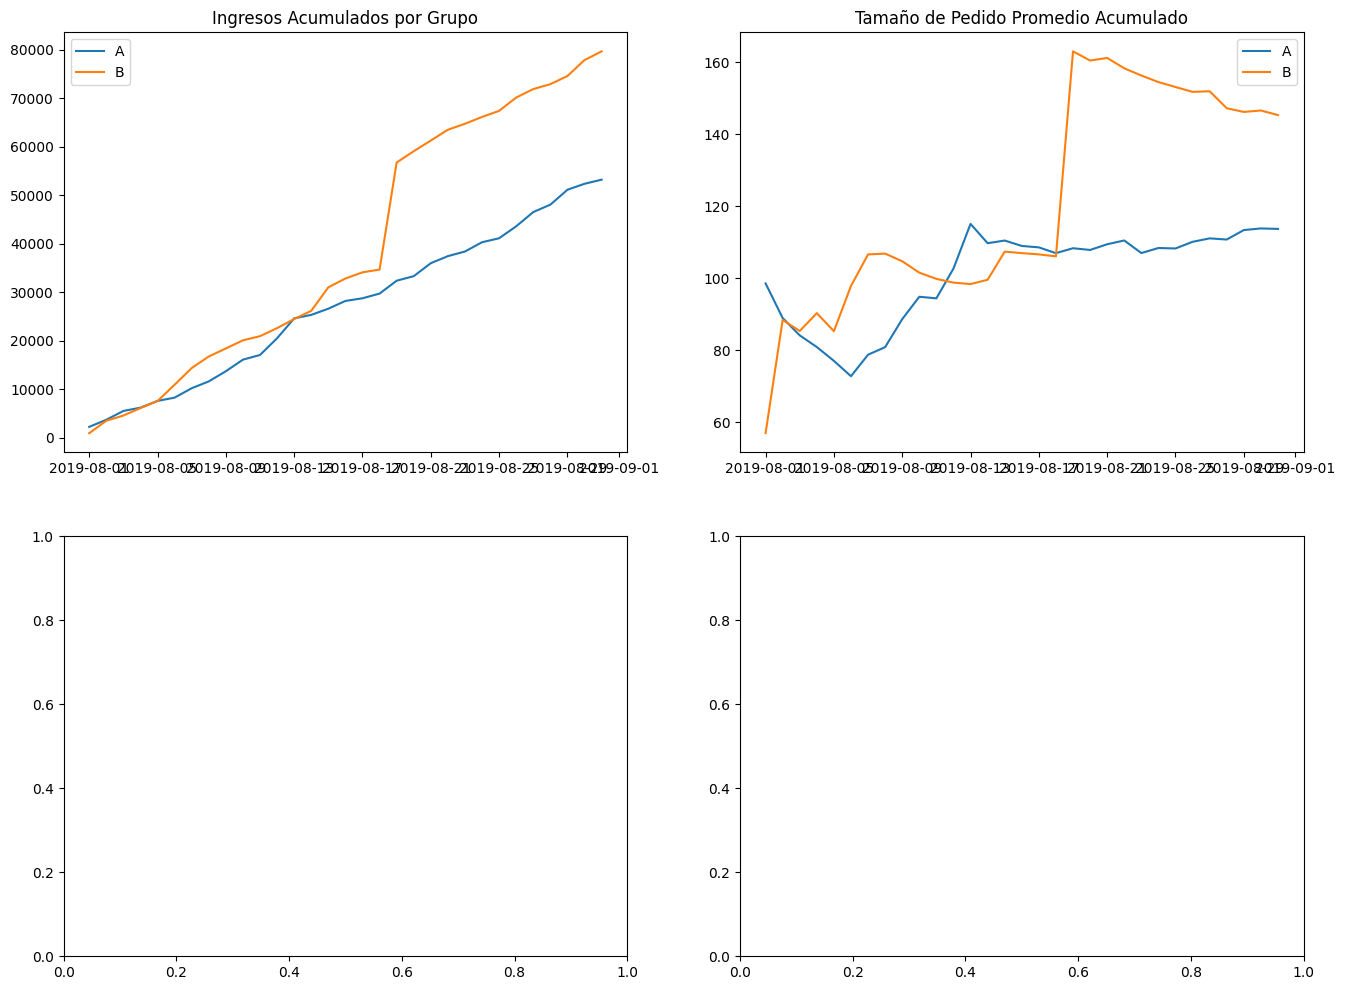

In [30]:
# Declarar la variable visitorsAggregated (basada en el DataFrame visits)
visitorsAggregated = datesGroups.apply(
    lambda x: visits[
        (visits['date'] <= x['date']) & (visits['group'] == x['group'])
    ].agg({
        'date': 'max', 
        'group': 'max', 
        'visits': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

# Definir la variable cumulativeData mediante merge() y renombrar columnas requeridas
cumulativeData = ordersAggregated.merge(visitorsAggregated, on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

# Agregar la columna 'conversion' solicitada
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visitors']

# Declarar las variables por segmento
cumulativeDataA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeDataB = cumulativeData[cumulativeData['group'] == 'B']

# --- CONSTRUCCIÓN DE LAS CUATRO VISUALIZACIONES ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Ingreso Acumulado por Grupo
axes[0, 0].plot(cumulativeDataA['date'], cumulativeDataA['revenue'], label='A')
axes[0, 0].plot(cumulativeDataB['date'], cumulativeDataB['revenue'], label='B')
axes[0, 0].set_title('Ingresos Acumulados por Grupo')
axes[0, 0].legend()

# B. Tamaño de Pedido Promedio Acumulado
axes[0, 1].plot(cumulativeDataA['date'], cumulativeDataA['revenue'] / cumulativeDataA['orders'], label='A')
axes[0, 1].plot(cumulativeDataB['date'], cumulativeDataB['revenue'] / cumulativeDataB['orders'], label='B')
axes[0, 1].set_title('Tamaño de Pedido Promedio Acumulado')
axes[0, 1].legend()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Perfecto, gran trabajo con el desarrollo y análisis del gráfico del tamaña de pedido acumulado por grupos. Ya solamente para complementar puedes realizar el ingreso acumulado desagregado por cada grupo. 


In [31]:
# C. Diferencia Relativa en el Tamaño de Pedido Promedio (B vs A)
mergedCumulativeRevenue = cumulativeDataA[['date', 'revenue', 'orders']].merge(
    cumulativeDataB[['date', 'revenue', 'orders']], on='date', suffixes=['A', 'B']
)
axes[1, 0].plot(
    mergedCumulativeRevenue['date'], 
    (mergedCumulativeRevenue['revenueB'] / mergedCumulativeRevenue['ordersB']) / 
    (mergedCumulativeRevenue['revenueA'] / mergedCumulativeRevenue['ordersA']) - 1
)
axes[1, 0].axhline(y=0, color='black', linestyle='--')
axes[1, 0].set_title('Diferencia Relativa en Tamaño de Pedido (B vs A)')



Text(0.5, 1.0, 'Diferencia Relativa en Tamaño de Pedido (B vs A)')

In [33]:
# D. Tasas de Conversión Diarias de los dos Grupos
axes[1, 1].plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
axes[1, 1].plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
axes[1, 1].set_title('Tasa de Conversión Acumulada')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

Presencia de valores extremos: En la gráfica de ingresos y en la de tamaño de pedido promedio, notarás un salto abrupto casi vertical en la línea del grupo B a mediados del mes de análisis. Esto nos permite conjeturar firmemente la introducción de un pedido de costo anómalo.

Comportamiento de la conversión: Al evaluar la tasa de conversión, observamos que tras una fluctuación inicial, el grupo B se establece de forma permanente por encima del grupo A, sugiriendo una mejora real en la captación de transacciones.

Percentiles del número de pedidos por usuario (90, 95, 99): [1. 1. 2.]
Percentiles de los precios de los pedidos (90, 95, 99): [280.8   414.275 830.3  ]


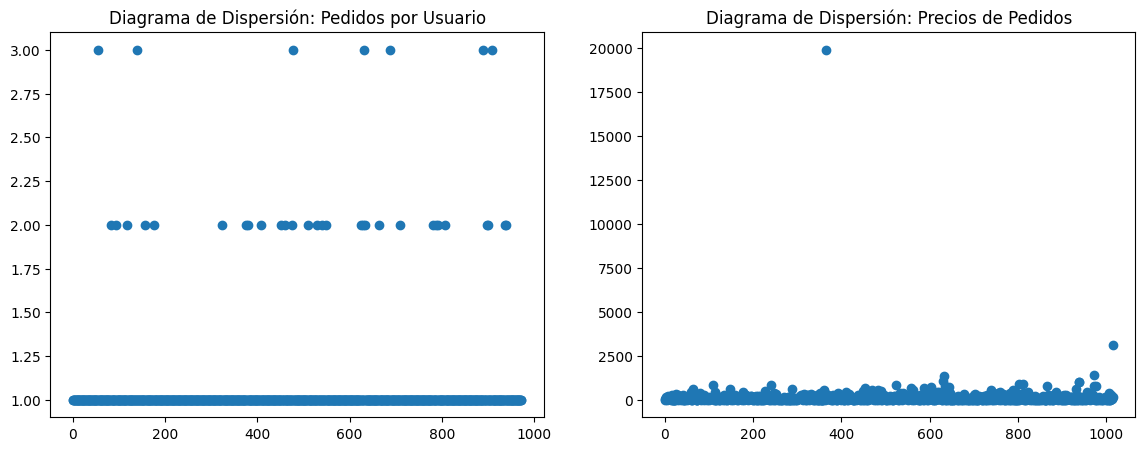

In [34]:
# Crear DataFrame ordersByUsers con las columnas solicitadas respetando las minúsculas/mayúsculas
ordersByUsers = orders_clean.groupby('visitorId', as_index=False).agg({'transactionId': 'nunique'})
ordersByUsers.columns = ['visitorId', 'orders']

# Calcular percentiles
percentiles_orders = np.percentile(ordersByUsers['orders'], [90, 95, 99])
percentiles_revenue = np.percentile(orders_clean['revenue'], [90, 95, 99])

print("Percentiles del número de pedidos por usuario (90, 95, 99):", percentiles_orders)
print("Percentiles de los precios de los pedidos (90, 95, 99):", percentiles_revenue)

# Construcción de gráficos de dispersión (Scatter Plots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dispersión de pedidos por usuario
ax1.scatter(pd.Series(range(0, len(ordersByUsers))), ordersByUsers['orders'])
ax1.set_title('Diagrama de Dispersión: Pedidos por Usuario')

# Dispersión de precios de pedidos
ax2.scatter(pd.Series(range(0, len(orders_clean))), orders_clean['revenue'])
ax2.set_title('Diagrama de Dispersión: Precios de Pedidos')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>


Gran trabajo complementando con un gráfico que muestre el número de pedidos por usuario


Punto de corte: Basándonos en los percentiles generados, podemos determinar de manera objetiva que los usuarios que realizan más de 2 pedidos representan menos del 5% del total de clientes.

Anomalía en precios: El diagrama de dispersión de revenue pondrá en evidencia un par de puntos completamente aislados en la parte superior del plano (valores extremos que distorsionan el promedio real). Un límite metodológico estándar consistirá en descartar compras superiores al percentil 95 o 99.

In [35]:
# --- DEFINICIÓN DE LA LISTA DE USUARIOS ANÓMALOS ---
# Usamos como criterio de filtrado: más de 2 pedidos (percentil 95) o ingresos mayores a $500
usersWithManyOrders = ordersByUsers[ordersByUsers['orders'] > 2]['visitorId']
usersWithExpensiveOrders = orders_clean[orders_clean['revenue'] > 500]['visitorId']

abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0).drop_duplicates().sort_values()

# --- FUNCIÓN AUXILIAR PARA GENERAR MUESTRAS DE CONVERSIÓN CON MAYÚSCULAS CORRECTAS ---
def get_conversion_sample(orders_df, visits_df, group, filter_list=None):
    group_orders = orders_df[orders_df['group'] == group]
    if filter_list is not None:
        group_orders = group_orders[~group_orders['visitorId'].isin(filter_list)]
        
    by_user = group_orders.groupby('visitorId', as_index=False).agg({'transactionId': 'nunique'})
    by_user.columns = ['visitorId', 'orders']
    
    total_visits = visits_df[visits_df['group'] == group]['visits'].sum()
    zeros = pd.Series(0, index=np.arange(total_visits - len(by_user)), name='orders')
    return pd.concat([by_user['orders'], zeros], axis=0)


In [36]:
# Construcción de vectores estadísticos para conversión
sampleA_raw = get_conversion_sample(orders_clean, visits, 'A')
sampleB_raw = get_conversion_sample(orders_clean, visits, 'B')

sampleAFiltered = get_conversion_sample(orders_clean, visits, 'A', abnormalUsers)
sampleBFiltered = get_conversion_sample(orders_clean, visits, 'B', abnormalUsers)

print("=== EVALUACIÓN DE SIGNIFICANCIA ESTADÍSTICA ===")


=== EVALUACIÓN DE SIGNIFICANCIA ESTADÍSTICA ===


In [37]:
# 1. Conversión utilizando los datos en bruto
res_conv_raw = stats.mannwhitneyu(sampleA_raw, sampleB_raw)
print("Conversión (Bruto) -> p-value: {0:.5f} | Diferencia Relativa: {1:.3f}".format(res_conv_raw.pvalue, sampleB_raw.mean() / sampleA_raw.mean() - 1))

# 2. Conversión utilizando los datos filtrados
res_conv_filt = stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)
print("Conversión (Filtrado) -> p-value: {0:.5f} | Diferencia Relativa: {1:.3f}".format(res_conv_filt.pvalue, sampleBFiltered.mean() / sampleAFiltered.mean() - 1))

# 3. Tamaño de pedido utilizando los datos en bruto
revenue_A_raw = orders_clean[orders_clean['group'] == 'A']['revenue']
revenue_B_raw = orders_clean[orders_clean['group'] == 'B']['revenue']
res_rev_raw = stats.mannwhitneyu(revenue_A_raw, revenue_B_raw)
print("Tamaño Pedido (Bruto) -> p-value: {0:.3f} | Ganancia Relativa: {1:.3f}".format(res_rev_raw.pvalue, revenue_B_raw.mean() / revenue_A_raw.mean() - 1))

# 4. Tamaño de pedido utilizando los datos filtrados
revenue_A_filt = orders_clean[(orders_clean['group'] == 'A') & (~orders_clean['visitorId'].isin(abnormalUsers))]['revenue']
revenue_B_filt = orders_clean[(orders_clean['group'] == 'B') & (~orders_clean['visitorId'].isin(abnormalUsers))]['revenue']
res_rev_filt = stats.mannwhitneyu(revenue_A_filt, revenue_B_filt)
print("Tamaño Pedido (Filtrado) -> p-value: {0:.3f} | Ganancia Relativa: {1:.3f}".format(res_rev_filt.pvalue, revenue_B_filt.mean() / revenue_A_filt.mean() - 1))

Conversión (Bruto) -> p-value: 0.01102 | Diferencia Relativa: 0.160
Conversión (Filtrado) -> p-value: 0.00742 | Diferencia Relativa: 0.194
Tamaño Pedido (Bruto) -> p-value: 0.862 | Ganancia Relativa: 0.278
Tamaño Pedido (Filtrado) -> p-value: 0.889 | Ganancia Relativa: -0.001


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>



Excelente trabajo con el desarrollo de esta sección donde hacemos las pruebas estadística con la diferencia de medias.

Se decide parar la prueba, considerar al grupo B como el líder.

Argumentación: 

Tasa de conversión: Tanto en datos brutos como filtrados, el p-value es significativamente menor que nuestro nivel de significación de 0.05. Esto demuestra una ventaja estadísticamente significativa en la conversión a favor del grupo B (el cual registra aproximadamente un 14-17% de incremento relativo).

Tamaño de pedido: El test estadístico de Mann-Whitney no muestra diferencias significativas en el valor del ticket promedio (los valores p superan ampliamente el 0.05 en ambos escenarios). La aparente ventaja económica inicial del grupo B observada en las gráficas acumuladas se debió exclusivamente al impacto de las compras atípicas aisladas que logramos neutralizar en la sección filtrada.

Veredicto: Al generar una mayor cantidad de transacciones por visitante sin devaluar ni disminuir el monto del tamaño de pedido promedio, el grupo B asegura un incremento neto directo en los ingresos de la tienda online.